# Real-time classification: from the benchmark to a live microphone

The noise-trained CNN (`cnn_noise`, 75% on the ESC-50 folds) now listens to the laptop microphone
([`scripts/realtime_demo.py`](../scripts/realtime_demo.py)): every hop H = 0.5 s, the latest W seconds
go through the training pipeline (22.05 kHz, 128-band log-mel, normalization) and the CNN, and the top 3
classes are shown. Two additions the benchmark never needed:

- **A level gate.** The CNN must answer one of its 50 classes, even for an empty room (it said
  *snoring* with 77%). The background level is measured at start-up, and a window is classified only if
  some 50 ms frame of it is 10 dB above it.
- **A confidence threshold.** Below a top-1 probability of 0.4 the demo says "not sure".

**How it was tested.** Sessions of 40 s recorded at home while repeating one sound: 5 ESC-50 classes
that can be produced at home (door knock, mouse click, keyboard typing, tooth brushing, breathing) and
two sounds that are *not* in ESC-50 (speech, music). The demo saves each session's audio, and
`realtime.replay` runs it again offline through exactly the same code as the live demo (same windows,
gate and smoothing), so different settings can be compared on the same sounds. Every session was
recorded twice: with the laptop's built-in microphone processing on (Waves MaxxAudio, Dell's default)
and off. The recordings are not published (`data/` is not committed).

Only windows with a sound event are scored. Each session gives ~80 strongly correlated windows of a
single person, room and microphone, so differences of a few points are noise.

In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from audiolab.audio_io import load_audio
from audiolab.esc50 import load_metadata
from audiolab.features import extract_logmel
from audiolab.realtime import (add_comfort_noise, class_probabilities, frame_levels_db, load_models,
                               replay, to_model_rate)

DATA = Path("../data")
HOME = DATA / "home"
meta = load_metadata(DATA / "ESC-50")
classes = meta.drop_duplicates("target").sort_values("target").category.to_numpy()
single = load_models(DATA / "models" / "cnn_noise")                        # the fold-1 model
ensemble = load_models(DATA / "models" / "cnn_noise", folds=range(1, 6))
BLUE, ORANGE, GREEN, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TEXT, MUTED = "#0b0b0b", "#52514e"


## 1. Latency budget

A sound that starts right after a prediction enters the next one at most H + C later (C: compute
time); after it ends it stays in the window, and on screen, for W seconds. So H sets the reaction
time and W the memory. C is negligible:

In [2]:
def time_ms(f, n=20):
    f()                                                    # warm-up: the first call is much slower
    start = time.perf_counter()
    for _ in range(n):
        f()
    return 1000 * (time.perf_counter() - start) / n

rng = np.random.default_rng(0)
rows = []
for W in (1, 2, 5):
    x = (0.01 * rng.standard_normal(int(W * 44100))).astype(np.float32)      # microphone rate
    rows.append({"window W (s)": W,
                 "resample + log-mel": time_ms(lambda: extract_logmel(to_model_rate(x, 44100), 22050)),
                 "+ 1 CNN": time_ms(lambda: class_probabilities(single, to_model_rate(x, 44100))),
                 "+ 5 CNNs (ensemble)": time_ms(lambda: class_probabilities(ensemble, to_model_rate(x, 44100)))})
pd.DataFrame(rows).set_index("window W (s)").style.format("{:.1f} ms")

,resample + log-mel,+ 1 CNN,+ 5 CNNs (ensemble)
window W (s),,,
1,2.7 ms,5.7 ms,12.5 ms
2,5.4 ms,7.9 ms,17.2 ms
5,8.5 ms,13.4 ms,29.2 ms


In [3]:
live = pd.concat([pd.read_csv(p) for p in (HOME / "enh_off").glob("*.csv")])
print(f"Measured live (W = 5 s, 1 model, {len(live)} predictions): compute median {live.compute_ms.median():.0f} ms, "
      f"95th percentile {live.compute_ms.quantile(0.95):.0f} ms")

Measured live (W = 5 s, 1 model, 567 predictions): compute median 10 ms, 95th percentile 13 ms


On top of that, PortAudio reports ~26 ms of input latency on this laptop (the time for a block of
samples to reach the program). With H = 0.5 s, the budget is dominated by the hop, not by the
computation: one model uses ~2-3% of one CPU core.

## 2. First test at home: 45%

The first sessions (microphone processing on) gave a much lower accuracy than the benchmark, and one
class appeared everywhere. Only their prediction logs were kept, and the door knock log was later
overwritten by a test with the same name, so it is left out:

In [4]:
first = pd.concat([pd.read_csv(p).assign(session=p.stem) for p in sorted((HOME / "first_run").glob("*.csv"))
                   if p.stem != "door_wood_knock"])
first = first[first.event == 1]
known = first[~first.session.str.startswith("other")]
per = known.assign(correct=known.top1 == known.session).groupby("session").correct.mean()
print(f"Top-1 over the {len(per)} ESC-50 sessions: {per.mean():.0%}  (cross-validation on ESC-50: 75%)")
print(f"Windows predicted as glass_breaking, in any session: {(first.top1 == 'glass_breaking').mean():.0%}")
per.to_frame("top-1").style.format("{:.0%}")

Top-1 over the 5 ESC-50 sessions: 41%  (cross-validation on ESC-50: 75%)
Windows predicted as glass_breaking, in any session: 24%


,top-1
session,
breathing,46%
brushing_teeth,55%
keyboard_typing,48%
mouse_click,58%
toilet_flush,0%


Glass breaking is the ESC-50 class with the most digital silence (54% of its frames are exact
zeros of padding), and the levels in the logs went down to -96 dBFS between sounds: digital
silence, which a microphone should never output. The suspect is the microphone processing.

## 3. The microphone's processing writes digital silence

In [5]:
def describe(path):
    y, sr = load_audio(path)
    levels = frame_levels_db(y, sr // 20)
    return {"exact zeros": np.mean(y == 0), "background (dBFS)": np.median(levels[:100]),
            "loudest 50 ms (dBFS)": levels.max()}

levels_table = pd.DataFrame({(fx, p.stem): describe(p) for fx in ("on", "off")
                             for p in sorted((HOME / f"enh_{fx}").glob("*.wav"))}).T
levels_table.index.names = ["processing", "session"]
levels_table.unstack(0).style.format({c: "{:.0%}" if c[0] == "exact zeros" else "{:.0f}" for c in levels_table.unstack(0).columns})

With the processing on, 14-64% of the samples are exact zeros and the background sits at -97 dBFS:
the processing includes a noise gate that mutes the microphone whenever it decides nothing is
happening. With it off, the background is the real room noise (~-63 dBFS) and the only zeros are the
first instants of the stream.

## 4. Accuracy with and without the processing, and comfort noise

If the problem is digital silence, a classic fix from telephony is **comfort noise**: during the
pauses of a call with discontinuous transmission nothing is sent, and the receiver plays a soft
noise instead of absolute silence. Here: add pink noise at a fixed level to the model input only (the
level gate still sees the real signal). Same 5 s windows and model as the first test.

In [6]:
def score(folder, models=single, window=5.0, comfort_db=None):
    """Replay every session in a folder. One row per window with a sound event."""
    rows = []
    for path in sorted(folder.glob("*.wav")):
        y, sr = load_audio(path)
        P, events = replay(y, sr, models, window=window, comfort_db=comfort_db)
        n, hop = int(window * sr), sr // 2
        zeros = np.array([np.mean(y[end - n:end] == 0) for end in range(n, len(y) + 1, hop)])
        P, zeros = P[events], zeros[events]
        ranked = np.argsort(P, axis=1)[:, ::-1]
        true = None if path.stem.startswith("other") else path.stem
        k = list(classes).index(true) if true else -1
        rows.append(pd.DataFrame({"session": path.stem, "known": true is not None, "pred": classes[ranked[:, 0]],
                                  "p1": P.max(axis=1), "correct": ranked[:, 0] == k,
                                  "top3": (ranked[:, :3] == k).any(axis=1), "zeros": zeros}))
    return pd.concat(rows, ignore_index=True)


def summary(w, min_prob=0.4):
    """Accuracy averaged over sessions (each weighs the same), and the effect of a confidence threshold."""
    known, other = w[w.known], w[~w.known]
    per = known.groupby("session")[["correct", "top3"]].mean()
    shown = known[known.p1 >= min_prob]
    return pd.Series({"top-1": per.correct.mean(), "top-3": per.top3.mean(),
                      "shown (p1 >= 0.4)": len(shown) / len(known), "accuracy of shown": shown.correct.mean(),
                      "speech/music shown": (other.p1 >= min_prob).mean(),
                      "glass_breaking": (w.pred == "glass_breaking").mean()})


COMFORT = {"none": None, "-80": -80, "-70": -70, "-60": -60, "-50": -50}
scored = {(fx, name): score(HOME / f"enh_{fx}", comfort_db=c) for fx in ("on", "off") for name, c in COMFORT.items()}
grid = pd.DataFrame({k: summary(w) for k, w in scored.items()}).T
grid.index.names = ["processing", "comfort noise (dBFS)"]
grid.style.format("{:.0%}")

In [7]:
per_session = pd.DataFrame({fx: scored[fx, "none"].query("known").groupby("session").correct.mean()
                            for fx in ("on", "off")})
mistake = lambda w: w[w.known & ~w.correct].groupby("session").pred.agg(lambda s: s.value_counts().index[0])
per_session["most common mistake (on)"] = mistake(scored["on", "none"])
per_session["most common mistake (off)"] = mistake(scored["off", "none"])
per_session.style.format({"on": "{:.0%}", "off": "{:.0%}"})

,on,off,most common mistake (on),most common mistake (off)
session,,,,
breathing,56%,59%,drinking_sipping,crickets
brushing_teeth,54%,62%,glass_breaking,water_drops
door_wood_knock,76%,81%,glass_breaking,sneezing
keyboard_typing,65%,69%,mouse_click,mouse_click
mouse_click,68%,90%,drinking_sipping,crackling_fire


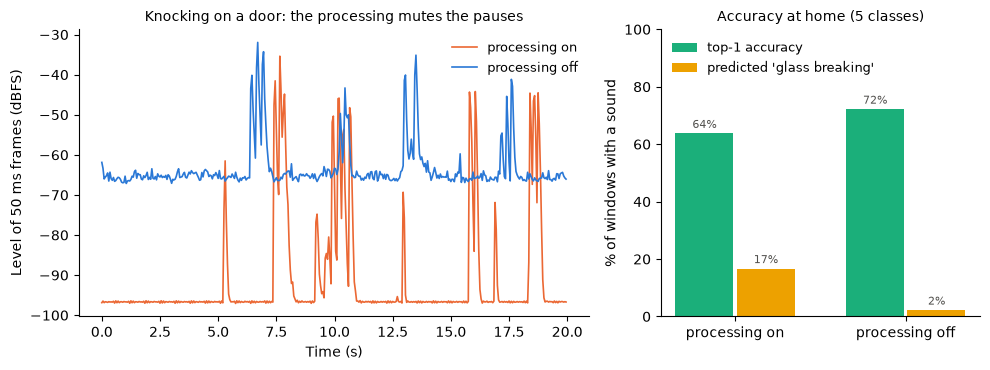

In [8]:
# README figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
for fx, color, label in [("on", ORANGE, "processing on"), ("off", BLUE, "processing off")]:
    y, sr = load_audio(HOME / f"enh_{fx}" / "door_wood_knock.wav")
    levels = frame_levels_db(y, sr // 20)[100:500]                     # 20 s after the calibration
    ax1.plot(np.arange(len(levels)) / 20, levels, color=color, linewidth=1.2, label=label)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Level of 50 ms frames (dBFS)")
ax1.set_title("Knocking on a door: the processing mutes the pauses", fontsize=10)
ax1.legend(loc="upper right", frameon=False, fontsize=9)

g = grid.xs("none", level=1)
x = np.arange(2)
for i, (col, label) in enumerate([("top-1", "top-1 accuracy"), ("glass_breaking", "predicted 'glass breaking'")]):
    bars = ax2.bar(x + (i - 0.5) * 0.36, g.loc[["on", "off"], col] * 100, width=0.34,
                   color=[GREEN, YELLOW][i], label=label)
    ax2.bar_label(bars, fmt="%.0f%%", fontsize=8, color=MUTED, padding=2)
ax2.set_xticks(x, ["processing on", "processing off"])
ax2.set_ylim(0, 100)
ax2.set_ylabel("% of windows with a sound")
ax2.set_title("Accuracy at home (5 classes)", fontsize=10)
ax2.legend(loc="upper left", frameon=False, fontsize=9)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

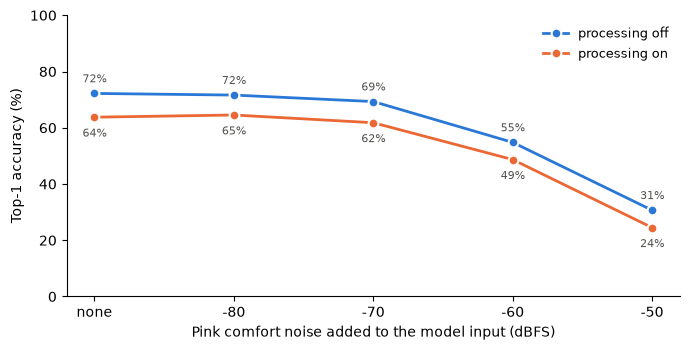

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.6))
labels = list(COMFORT)
for fx, color in [("off", BLUE), ("on", ORANGE)]:
    t = grid.loc[fx].loc[labels]
    ax.plot(labels, t["top-1"] * 100, color=color, linewidth=2, marker="o", markersize=7,
            markeredgecolor="#fcfcfb", markeredgewidth=1.5, label=f"processing {fx}")
    for i, v in enumerate(t["top-1"]):
        ax.annotate(f"{v:.0%}", (i, v * 100), xytext=(0, 8 if fx == "off" else -14), textcoords="offset points",
                    ha="center", fontsize=8, color=MUTED)
ax.set_xlabel("Pink comfort noise added to the model input (dBFS)")
ax.set_ylabel("Top-1 accuracy (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Why comfort noise did not help

Two separate questions: why it does not remove the glass breaking mistakes with the processing on, and
why it hurts even with the processing off.

In [10]:
w = scored["on", "none"]
gb = w.pred == "glass_breaking"
print(f"Processing on: exact zeros in the windows predicted as glass_breaking {w.zeros[gb].mean():.0%}, "
      f"in the other windows {w.zeros[~gb].mean():.0%}")
for name in ("none", "-60"):
    print(f"  comfort noise {name:>4}: glass_breaking in {(scored['on', name].pred == 'glass_breaking').mean():.0%} of the windows")

Processing on: exact zeros in the windows predicted as glass_breaking 59%, in the other windows 24%
  comfort noise none: glass_breaking in 17% of the windows
  comfort noise  -60: glass_breaking in 17% of the windows


In [11]:
y, sr = load_audio(HOME / "enh_off" / "door_wood_knock.wav")
quiet = to_model_rate(y[:5 * sr], sr)                                     # the calibration: the room alone
room = extract_logmel(quiet, 22050).mean(axis=1)
bands = [5, 20, 40, 60, 80, 100, 120]
mel_freqs = librosa.mel_frequencies(n_mels=128, fmax=11025)[bands].round()
spectra = {"room background": room[bands]}
for level in (-70, -60):
    pink = extract_logmel(add_comfort_noise(np.zeros_like(quiet), level, rng=0), 22050).mean(axis=1)
    spectra[f"pink {level} dBFS"] = pink[bands]
spectra = pd.DataFrame(spectra, index=pd.Index(mel_freqs, name="mel band (Hz)")).T
spectra.style.format("{:.0f} dB")

mel band (Hz),131.000000,524.000000,1051.000000,1804.000000,3096.000000,5316.000000,9125.000000
room background,-48 dB,-53 dB,-56 dB,-57 dB,-58 dB,-58 dB,-59 dB
pink -70 dBFS,-52 dB,-56 dB,-59 dB,-61 dB,-63 dB,-65 dB,-67 dB
pink -60 dBFS,-42 dB,-46 dB,-49 dB,-51 dB,-53 dB,-55 dB,-57 dB


## 6. Choosing the settings

With the processing off and no comfort noise: the window length W, and one model or the ensemble of
the 5 fold models (5 times the computation).

In [12]:
configs = {("5 s", "1 model"): dict(window=5.0), ("5 s", "ensemble"): dict(window=5.0, models=ensemble),
           ("2 s", "1 model"): dict(window=2.0), ("2 s", "ensemble"): dict(window=2.0, models=ensemble),
           ("1 s", "1 model"): dict(window=1.0)}
settings = {k: score(HOME / "enh_off", **kw) for k, kw in configs.items()}
choice = pd.DataFrame({k: summary(w) for k, w in settings.items()}).T
choice.index.names = ["window W", "model"]
choice.style.format("{:.0%}")

In [13]:
pd.DataFrame({f"W = {k[0]}": w.query("known").groupby("session").correct.mean()
              for k, w in settings.items() if k[1] == "1 model"}).style.format("{:.0%}")

,W = 5 s,W = 2 s,W = 1 s
session,,,
breathing,59%,62%,74%
brushing_teeth,62%,53%,54%
door_wood_knock,81%,72%,68%
keyboard_typing,69%,85%,90%
mouse_click,90%,87%,75%


**The confidence threshold.** For the chosen setting (W = 2 s, one model): how much of what is
shown is correct, and how much of the speech and music gets through, as the threshold grows.

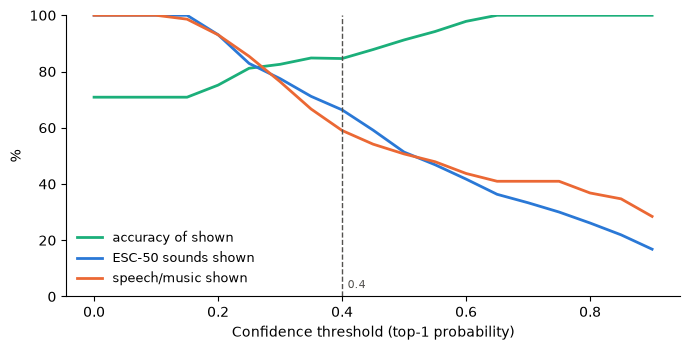

Mean top-1 probability: correct 0.65, wrong 0.33, speech/music 0.58
W = 5 s, 1 model : how well the confidence separates ESC-50 sounds from speech/music, AUROC = 0.52
W = 5 s, ensemble: how well the confidence separates ESC-50 sounds from speech/music, AUROC = 0.51
W = 2 s, 1 model : how well the confidence separates ESC-50 sounds from speech/music, AUROC = 0.48
W = 2 s, ensemble: how well the confidence separates ESC-50 sounds from speech/music, AUROC = 0.50
W = 1 s, 1 model : how well the confidence separates ESC-50 sounds from speech/music, AUROC = 0.48
Speech is mostly taken for: {'drinking_sipping': np.int64(38), 'insects': np.int64(9), 'pig': np.int64(5)}
Music is mostly taken for:  {'sheep': np.int64(62), 'sneezing': np.int64(3), 'breathing': np.int64(2)}


In [14]:
w = settings["2 s", "1 model"]
known, other = w[w.known], w[~w.known]
thresholds = np.arange(0, 0.91, 0.05)
curve = pd.DataFrame({"accuracy of shown": [known[known.p1 >= t].correct.mean() for t in thresholds],
                      "ESC-50 sounds shown": [(known.p1 >= t).mean() for t in thresholds],
                      "speech/music shown": [(other.p1 >= t).mean() for t in thresholds]}, index=thresholds)

fig, ax = plt.subplots(figsize=(7, 3.6))
for col, color in zip(curve, [GREEN, BLUE, ORANGE]):
    ax.plot(curve.index, curve[col] * 100, color=color, linewidth=2, label=col)
ax.axvline(0.4, color=MUTED, linewidth=1, linestyle="--")
ax.annotate("0.4", (0.4, 3), xytext=(4, 0), textcoords="offset points", fontsize=8, color=MUTED)
ax.set_xlabel("Confidence threshold (top-1 probability)")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Mean top-1 probability: correct {known.p1[known.correct].mean():.2f}, wrong {known.p1[~known.correct].mean():.2f}, "
      f"speech/music {other.p1.mean():.2f}")
for k, s in settings.items():
    kn, ot = s.p1[s.known], s.p1[~s.known]
    auc = roc_auc_score(np.r_[np.ones(len(kn)), np.zeros(len(ot))], np.r_[kn, ot])
    print(f"W = {k[0]}, {k[1]:8s}: how well the confidence separates ESC-50 sounds from speech/music, AUROC = {auc:.2f}")
print("Speech is mostly taken for:", dict(other[other.session == 'other_speech'].pred.value_counts().head(3)))
print("Music is mostly taken for: ", dict(other[other.session == 'other_music'].pred.value_counts().head(3)))

## Conclusions

- **Computation is not the bottleneck.** Resampling, log-mel and the CNN take ~10 ms per prediction
  (10 ms median live, 13 ms at the 95th percentile), 2% of a 0.5 s hop. The reaction time is set by
  the hop H and the memory by the window W; the 5-model ensemble doubles the total computation and is
  still affordable on a laptop, but not on a hearing aid.
- **The microphone's own processing was the main problem.** Dell's default processing (Waves
  MaxxAudio) mutes the microphone between sounds: 14-64% of the samples are exact zeros and the
  background drops to -97 dBFS. That digital silence brings back the shortcut the benchmark taught
  the network: windows predicted as glass breaking (the most padded ESC-50 class) contain 59% of zeros,
  versus 24% for the rest. Turning the processing off raises top-1 from 64% to **72%** (top-3: 80% →
  85%) and cuts the false glass breaking from 17% to 2% of the windows. 72% at home, with another
  microphone and room, is close to the 75% of cross-validation.
- **Comfort noise did not help.** Pink noise at -80 dBFS changes nothing, -70 dBFS costs 3 points and
  -60 dBFS costs 17 (72% → 55%; door knocks become sneezes), although it is only 2-7 dB above the real
  room background, and that is enough to change how the network sees short sounds in quiet rooms. It
  also leaves the glass breaking mistakes untouched (17% with and without), so the gate probably
  changes more than the pauses: it also cuts the tails of the sounds abruptly. The fix belongs in
  the signal chain, not after it: **a classifier should listen to the raw microphone signal**, which
  is how hearing aids do it, with the environment classifier steering the noise reduction rather than
  listening through it.
- **Settings: W = 2 s, one model, threshold 0.4.** The window length makes no difference on average
  (72% for 1, 2 and 5 s; single sessions move up to ±20 points either way), so the shorter memory wins: a
  sound leaves the screen 2 s after it ends instead of 5. The ensemble gives at most 3 points, within
  the noise of these sessions, for twice the computation (5 CNNs instead of 1). With a 0.4 threshold, 85% of what is shown
  is correct.
- **Sounds outside the 50 classes are the open problem.** The confidence separates right from wrong
  predictions (0.65 vs 0.33 on average) but not ESC-50 sounds from speech and music (AUROC ≈ 0.5 for
  every setting): speech is taken for drinking/sipping and music for sheep with the same confidence as
  a real knock. A threshold cannot fix that; it needs a model that knows speech and music, either an
  "other" class trained with them or a large pretrained model (AudioSet).
- Caveat: one person, one room, one microphone, 5 classes, and ~80 correlated windows per session.
  The direction of the effects is clear; differences of a few points are not.
